# 2. The Container Stacking Rules Problem

## Tier 4 — Reinforcement Learning (RL) augmentation (runnable, no heavy deps)

Tier 1–3 produce a stacking plan by solving/searching.

Tier 4 shows a different idea: **learn a stacking policy**.

Instead of writing a fixed rule, we train an agent that learns (approximately) which stack choice is good in a given state.

### Learning goals

- Understand the RL loop: state → action → reward → next state.
- See how a reward based on **reshuffle risk** can guide learning.
- Train and evaluate a simple agent without PyTorch/TensorFlow.

### What this notebook outputs

- Training curves (episode penalty / reshuffles)
- A greedy evaluation run (eps=0) on the example arrival order
- Stack + blocking visualizations for the learned policy

### Note

The source text mentions a DQN-style approach. Here we implement a **linear DQN-style** agent (fast and fully runnable).

In [1]:
# Environment check (no installs here)
#
# Best practice: dependencies should be preinstalled in the JupyterHub/Docker image.
# If you're running locally, install packages once in your Python environment.

from typing import List, Dict, Tuple, Deque, Optional

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "Missing dependency. Install: numpy, pandas, matplotlib. "
        "If you use the provided JupyterHub Docker image, these should already be installed."
    ) from e

# Reproducible randomness
rng = np.random.default_rng(0)

print("Dependencies imported successfully.")

Dependencies imported successfully.


## Problem setup (small environment)

We reuse the same small instance (5 containers, 3 stacks, 2 tiers).

The environment is sequential:

- At time step *t*, container *t* arrives.
- The agent chooses an action: **which stack to place it in**.
- The container is placed on top of that stack.
- The episode ends when all containers are placed.

### Reward intuition

We want to minimize reshuffles. A simple way to guide learning is to penalize:

- creating new blocking pairs (reshuffle risk)
- unbalanced stack heights
- weight instability (heavy over light)

So we use a negative reward (a penalty) when decisions increase these risks.

In [2]:
# ----------------------------
# Example data (same as earlier Tiers)
# ----------------------------

containers = [
    {"id": "C1", "d": 3, "w": 22},
    {"id": "C2", "d": 1, "w": 20},
    {"id": "C3", "d": 5, "w": 18},
    {"id": "C4", "d": 2, "w": 25},
    {"id": "C5", "d": 6, "w": 16},
]

NUM_STACKS = 3
MAX_TIERS = 2

cid_to_d = {c["id"]: c["d"] for c in containers}
cid_to_w = {c["id"]: c["w"] for c in containers}

arrival_order = [c["id"] for c in containers]

arrival_order

['C1', 'C2', 'C3', 'C4', 'C5']

In [3]:
# ----------------------------
# Helper functions: blocking metric and penalties
# ----------------------------
# We'll reuse the same *blocking pair* logic:
# A blocking pair exists in a stack when:
# - lower container departs earlier than an upper container
# This implies at least one reshuffle when retrieving the lower container.


def count_blocking_pairs_in_stack(stack_bottom_to_top: List[str]) -> int:
    reshuffles = 0
    for lower_idx in range(len(stack_bottom_to_top)):
        for upper_idx in range(lower_idx + 1, len(stack_bottom_to_top)):
            lower = stack_bottom_to_top[lower_idx]
            upper = stack_bottom_to_top[upper_idx]
            if cid_to_d[lower] < cid_to_d[upper]:
                reshuffles += 1
    return reshuffles


def count_total_reshuffles(stack_config: List[List[str]]) -> int:
    return sum(count_blocking_pairs_in_stack(stack) for stack in stack_config)


def blocking_created_by_placing(stack: List[str], arriving_cid: str) -> int:
    """How many new blocking pairs are created if we place arriving_cid on top of this stack?"""

    d_new = cid_to_d[arriving_cid]

    # Existing containers are lower than the arriving container.
    # Each existing container that departs earlier will become blocked by the arriving container.
    created = 0
    for existing_cid in stack:
        if cid_to_d[existing_cid] < d_new:
            created += 1

    return created


def weight_instability_created(stack: List[str], arriving_cid: str) -> int:
    """Return 1 if we place a heavier container on top of a lighter one (simple instability signal)."""

    if len(stack) == 0:
        return 0

    top = stack[-1]
    return 1 if cid_to_w[arriving_cid] > cid_to_w[top] else 0


def height_variance(heights: List[int]) -> float:
    """A small penalty term for unbalanced stack heights."""

    return float(np.var(np.array(heights, dtype=float)))


# Quick sanity checks
count_total_reshuffles([["C2", "C1"], [], []]), blocking_created_by_placing(["C2"], "C1"), weight_instability_created(["C3"], "C4")

(1, 1, 1)

## Environment and state representation

To train an RL agent, we need a Markov Decision Process (MDP):

- **State**: a numeric vector describing the current stacks + the arriving container
- **Action**: which stack index to place the arriving container into
- **Reward**: negative penalty capturing reshuffle risk + imbalance + instability

We keep the state small and interpretable so beginners can follow what each feature means.

In [4]:
# ----------------------------
# State encoding
# ----------------------------
# We convert the current yard state into a numeric vector.
# This is what the linear Q-function will use.
#
# Features (all normalized to roughly 0..1):
# - stack heights (3 values)
# - top container departure times per stack (3 values, 0 if empty)
# - top container weights per stack (3 values, 0 if empty)
# - arriving container departure time (1 value)
# - arriving container weight (1 value)
# - progress in the arrival sequence (1 value)

max_d = max(c["d"] for c in containers)
max_w = max(c["w"] for c in containers)


def encode_state(stack_config: List[List[str]], arriving_idx: int) -> np.ndarray:
    # Heights
    heights = np.array([len(s) / MAX_TIERS for s in stack_config], dtype=np.float32)

    # Top-of-stack info (departure time and weight)
    top_d = []
    top_w = []
    for s in stack_config:
        if len(s) == 0:
            top_d.append(0.0)
            top_w.append(0.0)
        else:
            cid = s[-1]
            top_d.append(cid_to_d[cid] / max_d)
            top_w.append(cid_to_w[cid] / max_w)

    top_d = np.array(top_d, dtype=np.float32)
    top_w = np.array(top_w, dtype=np.float32)

    # Arriving container features (or zeros if episode done)
    if arriving_idx >= len(arrival_order):
        arr_d = 0.0
        arr_w = 0.0
        progress = 1.0
    else:
        arr_cid = arrival_order[arriving_idx]
        arr_d = cid_to_d[arr_cid] / max_d
        arr_w = cid_to_w[arr_cid] / max_w
        progress = arriving_idx / max(1, len(arrival_order) - 1)

    arr = np.array([arr_d, arr_w, progress], dtype=np.float32)

    return np.concatenate([heights, top_d, top_w, arr])


# Quick sanity check
encode_state([[], [], []], 0), encode_state([["C1"], [], []], 1)

(array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 0.88,
        0.  ], dtype=float32),
 array([0.5       , 0.        , 0.        , 0.5       , 0.        ,
        0.        , 0.88      , 0.        , 0.        , 0.16666667,
        0.8       , 0.25      ], dtype=float32))

In [5]:
# ----------------------------
# Environment step function
# ----------------------------
# Action space: choose a stack index (0..NUM_STACKS-1)
# Invalid action: chosen stack is full
#
# Reward design (negative penalties):
# - blocking_created: discourages creating new blocking pairs
# - height_variance: discourages unbalanced stacks
# - weight_instability: discourages heavy-on-light
#
# At episode end, we add an extra penalty based on total reshuffles.


def valid_actions(stack_config: List[List[str]]) -> List[int]:
    return [i for i, s in enumerate(stack_config) if len(s) < MAX_TIERS]


def step_env(
    stack_config: List[List[str]],
    arriving_idx: int,
    action: int,
    w_block: float = 5.0,
    w_height_var: float = 1.0,
    w_weight: float = 2.0,
    terminal_reshuffle_weight: float = 3.0,
):
    """Perform one placement step.

    Returns:
    - new_stack_config
    - next_arriving_idx
    - reward
    - done
    - info dict
    """

    # Episode done if there is no arriving container
    if arriving_idx >= len(arrival_order):
        return stack_config, arriving_idx, 0.0, True, {"done": True}

    cid = arrival_order[arriving_idx]

    info = {
        "arriving": cid,
        "action": int(action),
        "invalid": False,
    }

    # Invalid action: full stack
    if len(stack_config[action]) >= MAX_TIERS:
        info["invalid"] = True
        # Large negative reward to teach the agent to avoid full stacks
        return stack_config, arriving_idx, -20.0, False, info

    # Compute penalties before placing
    block_created = blocking_created_by_placing(stack_config[action], cid)
    weight_created = weight_instability_created(stack_config[action], cid)

    # Place container
    new_stack_config = [s.copy() for s in stack_config]
    new_stack_config[action].append(cid)

    # Height variance after placement
    hv = height_variance([len(s) for s in new_stack_config])

    # Reward is negative penalty
    reward = -(
        w_block * float(block_created)
        + w_height_var * float(hv)
        + w_weight * float(weight_created)
    )

    next_idx = arriving_idx + 1
    done = next_idx >= len(arrival_order)

    # Terminal shaping: penalize total reshuffles at the end
    if done:
        total_resh = float(count_total_reshuffles(new_stack_config))
        reward -= terminal_reshuffle_weight * total_resh
        info["terminal_total_reshuffles"] = total_resh

    info.update(
        {
            "block_created": int(block_created),
            "weight_instability": int(weight_created),
            "height_variance": float(hv),
        }
    )

    return new_stack_config, next_idx, float(reward), bool(done), info


# Quick sanity check
cfg0 = [[], [], []]
cfg1, idx1, r1, done1, info1 = step_env(cfg0, 0, action=0)
(cfg1, idx1, r1, done1, info1)

([['C1'], [], []],
 1,
 -0.22222222222222224,
 False,
 {'arriving': 'C1',
  'action': 0,
  'invalid': False,
  'block_created': 0,
  'weight_instability': 0,
  'height_variance': 0.22222222222222224})

## Linear DQN-style agent (no neural networks)

A full DQN uses a neural network, but we can still demonstrate the core idea with a **linear function approximator**.

For each action (stack choice) we approximate:

- `Q(s, a) = w_a · s + b_a`

Where:

- `s` is the state feature vector
- `w_a` is a weight vector for action `a`
- `b_a` is a bias for action `a`

We train by minimizing the TD error (classic Q-learning update), using an experience replay buffer for stability.

In [6]:
# ----------------------------
# Linear DQN-style agent
# ----------------------------
# This is a small, readable implementation.
#
# Key pieces:
# - epsilon-greedy action selection
# - replay buffer
# - TD target update for a linear Q model

from collections import deque


class LinearDQN:
    def __init__(self, state_size: int, action_size: int, lr: float = 0.08, gamma: float = 0.98):
        self.state_size = state_size
        self.action_size = action_size

        # Learning rate and discount factor
        self.lr = lr
        self.gamma = gamma

        # One weight vector per action, plus bias
        self.W = rng.normal(0, 0.1, size=(action_size, state_size)).astype(np.float32)
        self.b = np.zeros((action_size,), dtype=np.float32)

        # Experience replay buffer
        self.memory = deque(maxlen=10000)

    def q_values(self, s: np.ndarray) -> np.ndarray:
        """Compute Q(s,·) for all actions."""
        return (self.W @ s) + self.b

    def act(self, s: np.ndarray, valid_acts: List[int], eps: float) -> int:
        """Epsilon-greedy action selection."""

        if rng.random() < eps:
            # Explore: choose a random valid action
            return int(rng.choice(valid_acts))

        # Exploit: choose the valid action with highest Q
        q = self.q_values(s)

        # Mask invalid actions by setting them to a very negative number
        masked = np.full_like(q, -1e9)
        for a in valid_acts:
            masked[a] = q[a]

        return int(np.argmax(masked))

    def remember(self, s: np.ndarray, a: int, r: float, s2: np.ndarray, done: bool, valid_acts2: List[int]):
        self.memory.append((s, a, r, s2, done, valid_acts2))

    def replay(self, batch_size: int = 64) -> float:
        """Train from a random batch of experiences.

        Returns mean squared TD error.
        """

        if len(self.memory) < batch_size:
            return 0.0

        idxs = rng.choice(len(self.memory), size=batch_size, replace=False)
        losses = []

        for idx in idxs:
            s, a, r, s2, done, valid_acts2 = self.memory[idx]

            # Current prediction
            q = self.q_values(s)

            # TD target
            target = float(r)
            if not done:
                q2 = self.q_values(s2)

                # Mask invalid next actions
                masked2 = np.full_like(q2, -1e9)
                for a2 in valid_acts2:
                    masked2[a2] = q2[a2]

                target = float(r) + self.gamma * float(np.max(masked2))

            # TD error
            err = target - float(q[a])

            # Gradient update for linear model
            # Q(s,a) = W[a]·s + b[a]
            self.W[a] += self.lr * err * s
            self.b[a] += self.lr * err

            losses.append(err * err)

        return float(np.mean(losses))


# Initialize agent
STATE_SIZE = int(encode_state([[], [], []], 0).shape[0])
ACTION_SIZE = NUM_STACKS

agent = LinearDQN(STATE_SIZE, ACTION_SIZE)

STATE_SIZE, ACTION_SIZE

(12, 3)

## Training loop

We train over many episodes.

Each episode:

- starts with empty stacks
- processes the same arrival order (C1→C5)
- ends after the last container is placed

We track:

- episode total reward (less negative is better)
- terminal total reshuffles
- TD loss (mean per episode)

This helps us see whether learning is improving decisions over time.

In [7]:
# ----------------------------
# Run one episode
# ----------------------------
# We return:
# - total_reward
# - terminal reshuffles
# - final stack config
# - a per-step log (for inspection)


def run_episode(eps: float, train: bool = True, max_steps: int = 20):
    stack_config: List[List[str]] = [[] for _ in range(NUM_STACKS)]
    arriving_idx = 0

    total_reward = 0.0
    losses = []

    step_log = []

    for t in range(max_steps):
        s = encode_state(stack_config, arriving_idx)

        # Find valid actions for this state
        vacts = valid_actions(stack_config)

        # Select action
        a = agent.act(s, vacts, eps=eps)

        # Step environment
        new_stack_config, next_idx, r, done, info = step_env(stack_config, arriving_idx, a)
        total_reward += float(r)

        # Next state
        s2 = encode_state(new_stack_config, next_idx)
        vacts2 = valid_actions(new_stack_config)

        if train:
            agent.remember(s, a, r, s2, done, vacts2)
            loss = agent.replay(batch_size=64)
            losses.append(loss)

        # Log (human-readable)
        step_log.append(
            {
                "t": t,
                "arriving": info.get("arriving", None),
                "action_stack": int(a) + 1,
                "reward": float(r),
                "block_created": info.get("block_created", None),
                "weight_instability": info.get("weight_instability", None),
                "height_variance": info.get("height_variance", None),
                "done": bool(done),
            }
        )

        stack_config, arriving_idx = new_stack_config, next_idx

        if done:
            break

    terminal_resh = int(count_total_reshuffles(stack_config))
    mean_loss = float(np.mean(losses) if losses else 0.0)

    return float(total_reward), terminal_resh, stack_config, pd.DataFrame(step_log), mean_loss


# Quick sanity check run
run_episode(eps=1.0, train=False)[:2]

(-4.888888888888888, 0)

In [8]:
# ----------------------------
# Train the agent
# ----------------------------
# We run many episodes and gradually reduce epsilon (exploration).

episodes = 1200

# Exploration schedule
eps0 = 1.0
eps_min = 0.05

decay = 0.995

ep_rewards = []
ep_reshuffles = []
ep_losses = []

eps = eps0
for ep in range(episodes):
    total_reward, terminal_resh, final_cfg, step_df, loss = run_episode(eps=eps, train=True)
    ep_rewards.append(total_reward)
    ep_reshuffles.append(terminal_resh)
    ep_losses.append(loss)

    eps = max(eps_min, eps * decay)

print("Training finished.")
print(f"Final epsilon: {eps:.3f}")
print(f"Last-50 avg reshuffles: {np.mean(ep_reshuffles[-50:]):.3f}")
print(f"Last-50 avg reward: {np.mean(ep_rewards[-50:]):.3f}")

Training finished.
Final epsilon: 0.050
Last-50 avg reshuffles: 0.120
Last-50 avg reward: -5.662


## Training curves

We visualize:

- episode total reward (should increase / become less negative)
- terminal reshuffles (should decrease)
- TD loss (can be noisy, but should not explode)

These are standard diagnostics in RL.

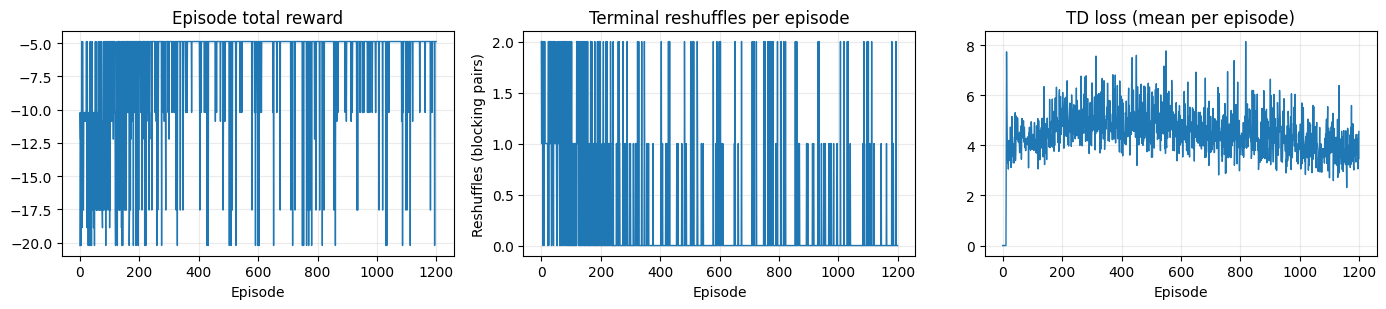

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))

# Episode total reward
axes[0].plot(ep_rewards, lw=1)
axes[0].set_title("Episode total reward")
axes[0].set_xlabel("Episode")
axes[0].grid(True, alpha=0.25)

# Terminal reshuffles
axes[1].plot(ep_reshuffles, lw=1)
axes[1].set_title("Terminal reshuffles per episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Reshuffles (blocking pairs)")
axes[1].grid(True, alpha=0.25)

# TD loss
axes[2].plot(ep_losses, lw=1)
axes[2].set_title("TD loss (mean per episode)")
axes[2].set_xlabel("Episode")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Greedy evaluation (after training)

Now we run one episode with `eps = 0`.

This shows what the agent would do when it stops exploring and acts greedily based on learned Q-values.

We will:

- print the step-by-step log
- visualize the final stack configuration
- compute blocking pairs / reshuffles
- plot reshuffles per container and cumulative reshuffles

In [10]:
# Run one greedy (no-exploration) episode after training
#
# This shows the learned policy's decisions on the same arrival order.

greedy_reward, greedy_resh, greedy_cfg, greedy_steps, _ = run_episode(eps=0.0, train=False)

print("Greedy total reward:", greedy_reward)
print("Greedy terminal reshuffles:", greedy_resh)
print("Greedy final config:", greedy_cfg)

greedy_steps

Greedy total reward: -4.888888888888888
Greedy terminal reshuffles: 0
Greedy final config: [['C3', 'C4'], ['C5'], ['C1', 'C2']]


,t,arriving,action_stack,reward,block_created,weight_instability,height_variance,done
0,0,C1,3,-0.222222,0,0,0.222222,False
1,1,C2,3,-0.888889,0,0,0.888889,False
2,2,C3,1,-0.666667,0,0,0.666667,False
3,3,C4,1,-2.888889,0,1,0.888889,False
4,4,C5,2,-0.222222,0,0,0.222222,True


## Solution quality check: how close is the learned policy to the exact optimum?

Because this example is small, we can compute the **true optimal reshuffle count** by exhaustive enumeration (Tier 1 style).

Then we compare it with the reshuffles achieved by the greedy policy learned by RL.

This makes it explicit whether the agent matched the optimum or not on the training instance.

In [11]:
# Exact optimum reshuffles (Tier 1 style) vs RL greedy policy reshuffles

import itertools


def apply_choice_sequence(choice_seq: Tuple[int, ...]) -> Optional[List[List[str]]]:
    stacks: List[List[str]] = [[] for _ in range(NUM_STACKS)]
    for cid, s_idx in zip(arrival_order, choice_seq):
        if len(stacks[s_idx]) >= MAX_TIERS:
            return None
        stacks[s_idx].append(cid)
    return stacks


all_choice_sequences = list(itertools.product(range(NUM_STACKS), repeat=len(arrival_order)))

opt_resh = None
for seq in all_choice_sequences:
    cfg = apply_choice_sequence(seq)
    if cfg is None:
        continue
    resh = int(count_total_reshuffles(cfg))
    if opt_resh is None or resh < opt_resh:
        opt_resh = resh

assert opt_resh is not None

print("Optimal reshuffles (exact):", int(opt_resh))
print("RL greedy reshuffles:", int(greedy_resh))
print("Gap (RL - optimal):", int(greedy_resh) - int(opt_resh))

Optimal reshuffles (exact): 0
RL greedy reshuffles: 0
Gap (RL - optimal): 0


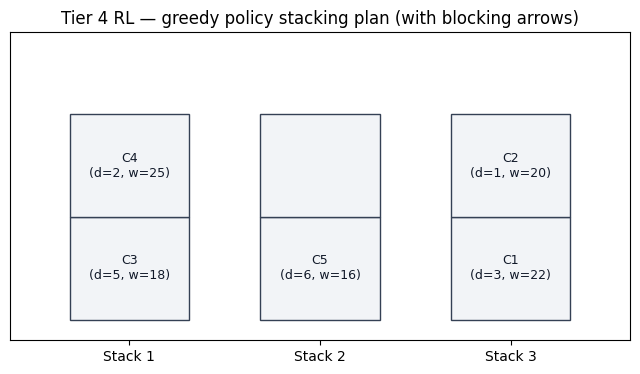

""


In [12]:
# ----------------------------
# Visualize the learned stacking plan (greedy policy)
# ----------------------------
# We show:
# - the stack layout
# - blocking arrows (upper blocks lower)


def blocking_pairs(stack_config: List[List[str]]) -> pd.DataFrame:
    pairs = []
    for s_idx, stack in enumerate(stack_config, start=1):
        for lower_idx in range(len(stack)):
            for upper_idx in range(lower_idx + 1, len(stack)):
                lower = stack[lower_idx]
                upper = stack[upper_idx]

                if cid_to_d[lower] < cid_to_d[upper]:
                    pairs.append(
                        {
                            "stack": s_idx,
                            "lower": lower,
                            "upper": upper,
                            "lower_departure": cid_to_d[lower],
                            "upper_departure": cid_to_d[upper],
                        }
                    )

    return pd.DataFrame(pairs)


blocking_df = blocking_pairs(greedy_cfg)

# Stack plot
fig, ax = plt.subplots(figsize=(8, 4))

stack_width = 1.0
cell_height = 1.0
x_gap = 0.6

stack_x = {s_idx: (s_idx - 1) * (stack_width + x_gap) for s_idx in range(1, NUM_STACKS + 1)}

# Draw empty slots
for s_idx in range(1, NUM_STACKS + 1):
    x0 = stack_x[s_idx]
    for tier in range(MAX_TIERS):
        rect = plt.Rectangle(
            (x0, tier * cell_height),
            stack_width,
            cell_height,
            facecolor="#F2F4F7",
            edgecolor="#344054",
        )
        ax.add_patch(rect)

# Labels
for s_idx, stack in enumerate(greedy_cfg, start=1):
    x0 = stack_x[s_idx]
    for tier, cid in enumerate(stack):
        ax.text(
            x0 + stack_width / 2,
            tier * cell_height + cell_height / 2,
            f"{cid}\n(d={cid_to_d[cid]}, w={cid_to_w[cid]})",
            ha="center",
            va="center",
            fontsize=9,
            color="#101828",
        )

# Blocking arrows
if len(blocking_df) > 0:
    for _, row in blocking_df.iterrows():
        s_idx = int(row["stack"])
        lower = row["lower"]
        upper = row["upper"]

        stack = greedy_cfg[s_idx - 1]
        lower_tier = stack.index(lower)
        upper_tier = stack.index(upper)

        x = stack_x[s_idx] + stack_width / 2
        y_lower = lower_tier * cell_height + cell_height / 2
        y_upper = upper_tier * cell_height + cell_height / 2

        ax.annotate(
            "",
            xy=(x, y_lower),
            xytext=(x, y_upper),
            arrowprops=dict(arrowstyle="->", lw=2, color="#F97066"),
        )

ax.set_title("Tier 4 RL — greedy policy stacking plan (with blocking arrows)")
ax.set_xticks([stack_x[s] + stack_width / 2 for s in range(1, NUM_STACKS + 1)])
ax.set_xticklabels([f"Stack {s}" for s in range(1, NUM_STACKS + 1)])
ax.set_yticks([])
ax.set_xlim(-0.5, stack_x[NUM_STACKS] + stack_width + 0.5)
ax.set_ylim(-0.2, MAX_TIERS * cell_height + 0.8)
plt.show()

blocking_df

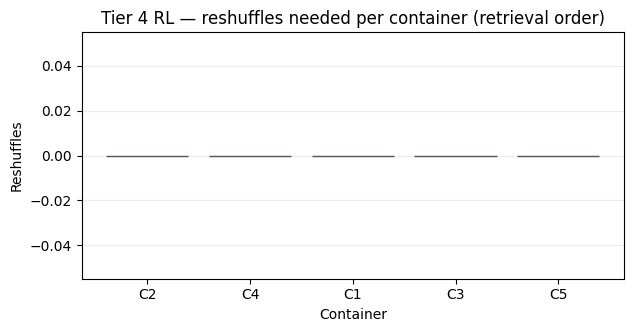

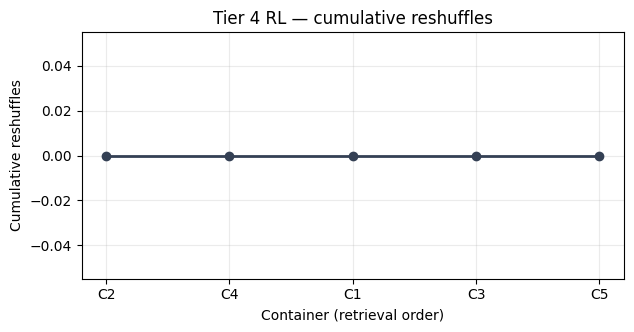

,container,d,reshuffles
0,C2,1,0
1,C4,2,0
2,C1,3,0
3,C3,5,0
4,C5,6,0


In [13]:
# ----------------------------
# Reshuffles per container + cumulative reshuffles (greedy policy)
# ----------------------------

block_counts = {c["id"]: 0 for c in containers}

if len(blocking_df) > 0:
    for _, r in blocking_df.iterrows():
        block_counts[r["lower"]] += 1

# Retrieval order
retrieve_order = sorted([c["id"] for c in containers], key=lambda cid: cid_to_d[cid])
resh_per = [block_counts[cid] for cid in retrieve_order]

plt.figure(figsize=(7, 3.2))
plt.bar(retrieve_order, resh_per, color="#2E90FA", edgecolor="#101828", alpha=0.85)
plt.title("Tier 4 RL — reshuffles needed per container (retrieval order)")
plt.xlabel("Container")
plt.ylabel("Reshuffles")
plt.grid(True, axis="y", alpha=0.25)
plt.show()

cum = np.cumsum(resh_per)
plt.figure(figsize=(7, 3.2))
plt.plot(retrieve_order, cum, marker="o", lw=2, color="#344054")
plt.title("Tier 4 RL — cumulative reshuffles")
plt.xlabel("Container (retrieval order)")
plt.ylabel("Cumulative reshuffles")
plt.grid(True, alpha=0.25)
plt.show()

pd.DataFrame({"container": retrieve_order, "d": [cid_to_d[c] for c in retrieve_order], "reshuffles": resh_per})

## Why this Tier exists vs earlier Tiers (comparison)

### Why Tier 4 exists (vs Tier 1–3)

Tier 1–3 are “solve/search for a plan” approaches.

Tier 4 exists for settings where you want to learn a **policy** that can be reused:

- many repeated stacking problems
- changing conditions
- online decision making

### Advantages vs Tier 1–3

- Learns from interaction and can generalize to similar instances
- Can be adapted online (continue training)
- Naturally fits sequential decision problems

### Disadvantages vs Tier 1–3

- Needs training episodes and careful reward design
- Learning can be unstable
- Harder to guarantee quality than exact optimization

### When to use Tier 4

- You have many similar instances (or a simulator)
- You want a decision policy rather than a one-off optimizer
- You can evaluate safely before deployment

## Common pitfalls

- If training does not improve:
  - Adjust reward weights (`w_block`, `w_height_var`, `w_weight`, `terminal_reshuffle_weight`).
  - Increase episodes.
  - Decrease learning rate.
- If the agent chooses invalid (full-stack) actions too often:
  - Increase invalid action penalty.
  - Verify `valid_actions` is correct.

## Next steps

- Train on randomized instances (different departure times/weights) so the policy learns to generalize.
- Replace the linear model with a small neural network if needed (heavier dependency).